<center>
<img src="https://raw.githubusercontent.com/FUlyankin/r_probability/master/end_seminars_2020/sem08/real_expect.png" width="500">

# Домашнее задание 9: KS-тест и хи-квадрат тесты
</center>

**ФИО:** Гаврин Глеб Юрьевич

## Общая информация

- [Лекция](https://youtu.be/LjZcrMiM9Ss)
- [Полезные блокноты](https://github.com/FUlyankin/matstat-AB/blob/main/week10_nonparam_bootstrap/04_05_python_kolmogorov_pearson.ipynb)

__Дата выдачи:__ 01.06.2024

__Дедлайн:__ 23:59MSK 20.06.2024

In [168]:
import numpy as np
import pandas as pd

from scipy import stats as sts

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')
%matplotlib inline

## Задание 1 (однородная игра)

Киллер - это весёлая лагерная игра. Краткие правила игры:

- Игроки пишут свои имена на карточках и кладут их в шляпу
- Игроки рандомно вытаскивают карточки из шляпы 
- Полученное имя - имя жертвы
- Каждый игрок одновременно и убийца и жертва
- Чтобы убить другого игрока, надо оказаться с ним наедине и застрелить из пальца
- Жертва убитого становится новой жертвой игрока
- Побеждает тот, кто совершит наибольшее число убийств

На экономическом факультете было два раунда игры в киллера. Все убийства регистрировались в гугл-форме. В табличках `killer_time1.csv` и `killer_time2.csv` лежит время в часах, которое проходило между убийствами.

In [169]:
killer1 = pd.read_csv("killer_time1.csv").hours_between_kill.values
killer2 = pd.read_csv("killer_time2.csv").hours_between_kill.values

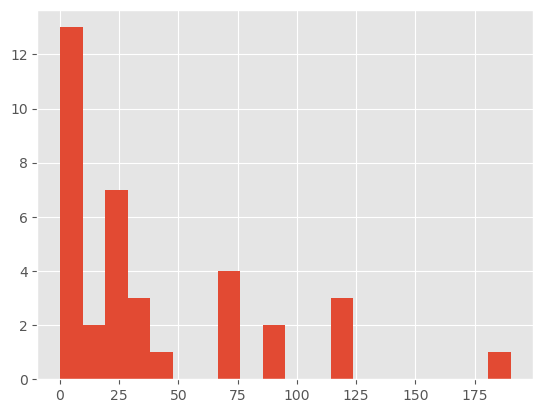

In [170]:
plt.hist(killer1, bins=20)
plt.show()

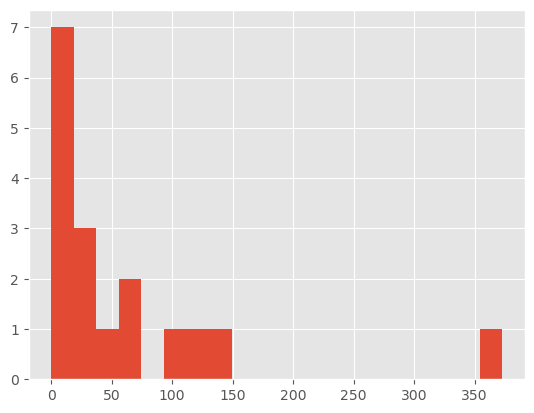

In [171]:
plt.hist(killer2, bins=20)
plt.show()

Мы хотим проверить гипотезу о том, что игры с точки зрения времени между убийствами прошли одинаково. Люди одинаково сильно были вовлечены в оба раунда игры и не потеряли энтузиазм. 

__а) [1 балл]__ Проверьте гипотезу об однородности выборок с помощью [теста Манна-Уитни.](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html) 

Как мы видим выше, распределения не нормальные, поэтому тест Манна-Уитни подходит

In [172]:
from scipy.stats import mannwhitneyu

In [173]:
statistic_U, p_value_U = mannwhitneyu(killer1, killer2, alternative='two-sided') # двухсторонняя альтернатива, так как время могло измениться в обе стороны
print(f'p-value в тесте Манна-Уитни об однородности выборок = {round(p_value_U, 4)}')

p-value в тесте Манна-Уитни об однородности выборок = 0.4867


p-value > 0.05 => не отвергаем нулевую гипотезу => **нет статистически значимых доказательств, что одна из выборок систематически сдвинута относительно другой**

__б) [1 балл]__ Распределение выглядит, как экспоненциальное. Более того, по гистограммам возникает ощущение, что это одинаковое распределение. С помощью теста Колмогорова-Смирнова проверьте гипотезу о том, что обе выборки пришли из одного и того же распределения.

In [174]:
from scipy.stats import ks_2samp

In [175]:
statistic_ks, p_value_ks = ks_2samp(killer1, killer2, alternative='two-sided') # двухсторонняя альтернатива, так как время могло измениться в обе стороны
print(f'p-value в тесте Колмогорова-Смирнова о происхождении выборок из одного распределения = {round(p_value_ks, 4)}')

p-value в тесте Колмогорова-Смирнова о происхождении выборок из одного распределения = 0.5453


p-value > 0.05 => не отвергаем нулевую гипотезу => **нет статистически значимых доказательств , что выборки происходят из разных распределений**

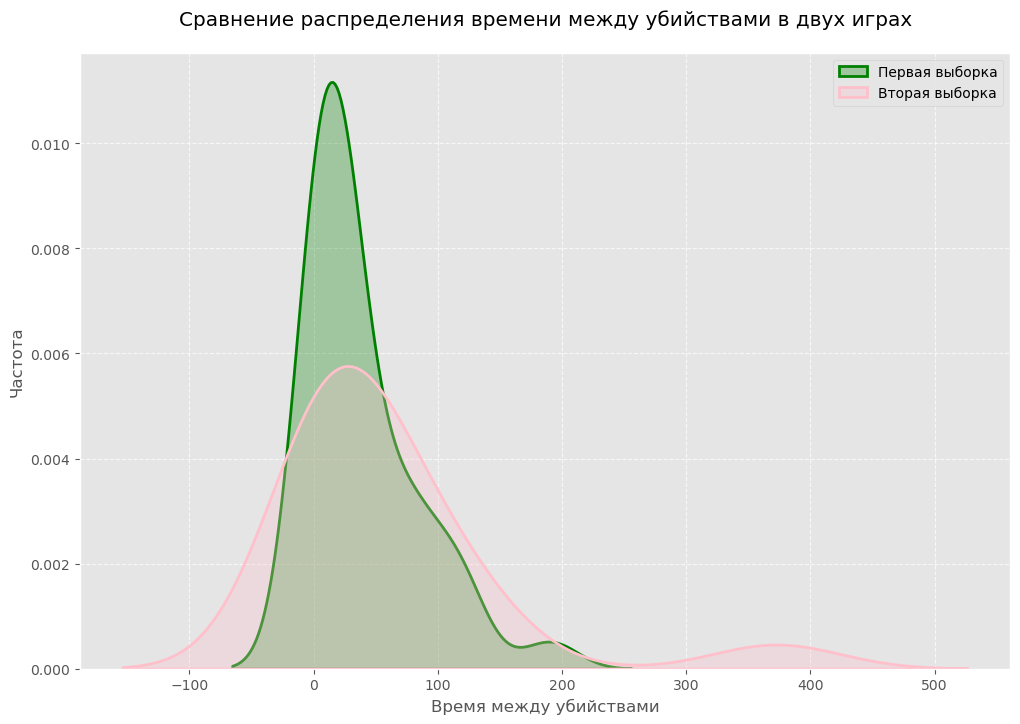

In [176]:
plt.figure(figsize=(12, 8), dpi=100)
sns.kdeplot(
    data=killer1,
    color="green",
    label="Первая выборка",
    linewidth=2,
    fill=True,
    alpha=0.3,
)

sns.kdeplot(
    data=killer2,
    color="pink",
    label="Вторая выборка",
    linewidth=2,
    fill=True,
    alpha=0.3,
)

plt.title("Сравнение распределения времени между убийствами в двух играх", pad=20)
plt.xlabel("Время между убийствами")
plt.ylabel("Частота")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.7)

plt.show()

__в) [3 балла]__ Ответьте на вопросы: 

- Какая гипотеза проверяется в тесте Манна-Уитни? Подходит ли этот тест для данной задачи? 

__Ответ:__ В тесте Манна-Уитни проверяется гипотеза, не сдвинуты ли распределения в двух выборках относительно друг друга. То есть это тест скорее про центральные тенденции

- Какая гипотеза проверятеся в KS-тесте? 

__Ответ:__ В KS-тесте проверяется, происходят ли выборки из одного распределения. То есть учитываются все характеристики распределений (среднее, дисперсия, хвосты, форма)

- Какой тест вы бы вырали для решения задачи?

__Ответ:__ Я бы выбрал для такой задачи тест Колмогорова-Смирнова, так как нам интересны различия между ритмом игры в первом и втором раунде. KS тест проверяет полное соответствие между распределениями. Не только среднюю интенсивность, но и паттерны активности (разброс, форму распределений).

## Задание 2 (парадокс Симпсона)

Помимо решения задач и применения различных функций из библиотек необходимо очень аккуратно работать с данным и понимать, какие действия корректны, а какие нет. Перед вами результаты медицинских исследований: 

- из $1650$ мужчин, принимавших лекарство, выздоровели $770$, 
- из $223$ мужчин, не принимавших лекарство, выздоровели $88$,
- из $245$ женщин, принимавших лекарство, выздоровели $165$,
- из $750$ женщин, не принимавших лекарство женщин, выздоровели $440$.

Необходимо найти ответы на следующие вопросы: 

1. Влияет ли лекарство на мужчин?
2. Влияет ли лекарство на женщин? 
3. Влияет ли лекарство на людей обоих полов в целом?

Будем считать, что исследование проводилось методом двойного слепого тестирования. Врач не знал, даёт ли он пациенту плацебо или лекарство, пациент не знал, пьёт ли он плацебо или лекарство. 

Запишем данные в табличку. Пусть $A$ — принимавшие лекарство, $\overline{A}$ — не принимавшие лекарство, $B$ — выздоровевшие, $\overline{B}$ — не выздоровевшие.

<!--<img width="60%" src="pics/pic2.png">-->
<table>
<tr><td>
    
|Мужчины| $B$ |  $\overline{B}$|
|--|--|--|
|$A$| 770 | 880 |
|$\overline{A}$| 88 | 135 |

</td><td>
    
|Женщины| $B$ |  $\overline{B}$|
|--|--|--|
|$A$| 165 | 80 |
|$\overline{A}$| 440 | 310 |

</td><td>

|Вместе| $B$ |  $\overline{B}$|
|--|--|--|
|$A$| 935 | 960 |
|$\overline{A}$| 528 | 445 |

</td></tr> </table>

Для решения задачи воспользуйтесь критерием хи-квадрат Пирсона.

Тест поможет нам понять, есть ли у лекарства какой-то эффект. Применить тест в python помогает функция `chi2_contingency` из пакета `scipy.stats`. Используйте её с параметром `correction=False`.

__а) [1 балл]__  Давайте попробуем найти ответ на вопрос, есть ли эффект от лекарства для мужчин?  Давайте предварительно посчитаем долю выздровевших мужчин, которые принимали лекарство и долю выздровевших мужчин, которые не принимали лекартсво. Сравните эти доли.

In [177]:
share_recovered_men_treatment = 770 / (770 + 880) # выздоровевшие и принимавшие / (выздоровевшие принимавшие + не выздоровевшие принимавшие)

share_recovered_men_no_treatment = 88 / (88 + 135) # выздоровевшие и непринимавшие / (выздоровевшие непринимавшие + не выздоровевшие непринимавшие)

round(share_recovered_men_treatment, 4), round(share_recovered_men_no_treatment, 4)

(0.4667, 0.3946)

**Разница в долях достаточно большая на глаз. Надо проверить, статистически значима ли эта разница**

Создадим матрицу размера $2 \times 2.$ Внесём в неё частоты, полученные для мужчин.

In [178]:
men = np.array([[770,880],[88,135]])
men

array([[770, 880],
       [ 88, 135]])

In [179]:
from scipy.stats import chi2_contingency  
from scipy.stats import chi2

Примените тест с параметром `correction=False` и сделайте выводы на уровне значимости $5\%.$

In [180]:
chi2_0, p_value_chi2, dof, expected = chi2_contingency(men, correction=False)  
print(f'p-value в тесте хи-квадрат Пирсона о независимости двух категориальных переменных = {round(p_value_chi2, 5)}')

p-value в тесте хи-квадрат Пирсона о независимости двух категориальных переменных = 0.04268


In [181]:
expected

array([[755.84623599, 894.15376401],
       [102.15376401, 120.84623599]])

На уровне значимости 5% выявлена статистически значимая связь для мужчин. Но p-value очень близко к 5%. Посмотрим на силу связи с помощью критерия Крамера:

In [182]:
n = men.sum() # общее количество наблюдений
min_dim = min(men.shape) - 1 
cramers_v = np.sqrt(chi2_0 / (n * min_dim))
print(f'Значение V-критерия Крамера = {round(cramers_v, 4)}')

Значение V-критерия Крамера = 0.0468


**Сила обнаруженной связи крайне мала** => по значению p-value и критерию Крамера можно сделать вывод, что **статистически значимая связь между переменными есть, но она очень слабая**

__б) [1 балл]__ Сделайте всё то же самое, но руками, без помощи библиотеки.

Для того, чтобы расчитать тестовую стаститику хи-квадрат, нам необходимо найти матрицу ожидаемых частот, такую же, которая у нас получилась в предыдущем пункте в output-е функции `chi2_contingency`. 

Используя матрицу из предыдущего пункта, посчитайте общее количество испытуемых мужчин.

In [183]:
N = men.sum() # всего
row_sums = men.sum(axis=1)  # Сумма по строкам
col_sums = men.sum(axis=0)  # Сумма по столбцам

expected = np.zeros_like(men, dtype=float) # матрица ожидаемых частот

for i in range(men.shape[0]):  
    for j in range(men.shape[1]):  
        expected[i, j] = (row_sums[i] * col_sums[j]) / N

chi2_stat = 0
for i in range(men.shape[0]):
    for j in range(men.shape[1]):
        chi2_stat += ((men[i, j] - expected[i, j]) ** 2) / expected[i, j] # расчет хиквадрат статистики



# степени свободы
dof = (men.shape[0] - 1) * (men.shape[1] - 1)

p_value_my = 1 - chi2.cdf(chi2_stat, dof)

print(f'p-value в тесте хи-квадрат Пирсона о независимости двух категориальных переменных, рассчитанный руками = {round(p_value_my, 5)}')

p-value в тесте хи-квадрат Пирсона о независимости двух категориальных переменных, рассчитанный руками = 0.04268


In [184]:
expected

array([[755.84623599, 894.15376401],
       [102.15376401, 120.84623599]])

In [185]:
col_sums

array([ 858, 1015])

Посчитайте отдельно количество испытуемых мужчин, которые принимали лекарство, и которые не принимали его $(n1, n2)$

In [186]:
men

array([[770, 880],
       [ 88, 135]])

In [187]:
N = men.sum() # всего
n1 = men.sum(axis=1)[0]  
n2 = men.sum(axis=1)[1]  
n1, n2

(1650, 223)

Найдите вероятности выздороветь или нет (независимо от группы по приему/не приему лекарства), то есть вероятность попасть в $B$ и $\overline{B}$ для мужчин.

In [188]:
prob_B = (770 + 88) / N
prob_noB = (880 + 135) / N

In [189]:
prob_B# + prob_noB

0.4580886278697277

Расчитайте ожидаемые (теоритические) значения для каждой ячейки матрицы. Для этого перемножьте вероятности из предыдущего пункта со значениями $n_1$ и $n_2$. Полученную матрицу можно сравнить с выводом библиотеки`scipy.stats`, она должна быть идентичной.

In [190]:
expected_my = np.zeros_like(men, dtype=float) # матрица ожидаемых частот
ns = [n1, n2]
probs = [prob_B, prob_noB]
for x in range(len(ns)):
    for y in range(len(probs)):
        expected_my[x, y] = ns[x] * probs[y]

In [191]:
expected_my

array([[755.84623599, 894.15376401],
       [102.15376401, 120.84623599]])

In [192]:
expected_my == expected

array([[ True,  True],
       [ True,  True]])

Расчитайте наблюдаемую статистику и найдите `p_value` с помощью `sts.chi2.cdf` с параметром `df=1`.

\begin{equation*} \chi^2_d = \sum {\frac {(O-E)^2}{E}},\end{equation*}

где

- $E$ - наши ожидаемые частоты(матрица из предыдущего пукта),
- $O$ - наблюдаемы частоты(первоначальная матрица).

In [194]:
chi2_stat = 0
for i in range(men.shape[0]):
    for j in range(men.shape[1]):
        chi2_stat += ((men[i, j] - expected_my[i, j]) ** 2) / expected_my[i, j] # расчет хиквадрат статистики


p_value_my = 1 - chi2.cdf(chi2_stat, df=1)

print(f'p-value в тесте хи-квадрат Пирсона о независимости двух категориальных переменных, рассчитанный руками = {round(p_value_my, 5)}')        

p-value в тесте хи-квадрат Пирсона о независимости двух категориальных переменных, рассчитанный руками = 0.04268


__в) [1 балл]__  Ответьте на вопрос: есть ли эффект от лекарства для женщин? (повторите процедуру пункта а) 

Как и в предыдущий раз, для начала, посчитайте долю выздровевших женщин, которые принимали лекарство и долю выздровевших женщин, которые не принимали лекартсво. Сравните эти доли.

In [198]:
share_recovered_women_treatment = 165 / (165 + 80) # выздоровевшие и принимавшие / (выздоровевшие принимавшие + не выздоровевшие принимавшие)

share_recovered_women_no_treatment = 440 / (440 + 310) # выздоровевшие и непринимавшие / (выздоровевшие непринимавшие + не выздоровевшие непринимавшие)

round(share_recovered_women_treatment, 4), round(share_recovered_women_no_treatment, 4)

(0.6735, 0.5867)

**Относительное различие в долях достаточно существенное**

Создайте матрицу с данными из таблицы по женщинам, примените тест с параметром `correction=False` и сделайте выводы на уровене значимости $5\%$.

In [199]:
women = np.array([[165,80],[440,310]])

chi2_0, p_value_chi2, dof, expected = chi2_contingency(women, correction=False)  
print(f'p-value в тесте хи-квадрат Пирсона о независимости двух категориальных переменных  для женщин= {round(p_value_chi2, 5)}')

p-value в тесте хи-квадрат Пирсона о независимости двух категориальных переменных  для женщин= 0.01568


Для женщин тоже обнаружена статистически-значимая взаимосвязь

__г) [1 балл]__ Ответьте на вопрос: есть ли эффект от лекарства для объединенной группы?

In [201]:
share_recovered_treatment = 935 / (935 + 960) # выздоровевшие и принимавшие / (выздоровевшие принимавшие + не выздоровевшие принимавшие)

share_recovered_no_treatment = 528 / (528 + 445) # выздоровевшие и непринимавшие / (выздоровевшие непринимавшие + не выздоровевшие непринимавшие)

round(share_recovered_treatment, 4), round(share_recovered_no_treatment, 4)

(0.4934, 0.5427)

In [200]:
united = np.array([[935,960],[528,445]])

chi2_0, p_value_chi2, dof, expected = chi2_contingency(united, correction=False)  
print(f'p-value в тесте хи-квадрат Пирсона о независимости двух категориальных переменных  для объединенной группы = {round(p_value_chi2, 5)}')

p-value в тесте хи-квадрат Пирсона о независимости двух категориальных переменных  для объединенной группы = 0.01249


Эффект значимый, при этом отрицательный, то есть **доля выздоровевших среди непринимавших выше**

__д) [1 балл]__  Соотносится ли это с результатами по группам мужчин и женщин, взятых отдельно?

**Не соотносится. Наблюдаем парадокс Симпсона.**

## Что произошло?

Если вы все сделали правильно, скорее всего у вас получились противоречивые значимые результаты. Давайте разберемся почему это так.

Может произойти такая ситуация, что новое лекарство может оказаться эффективным в каждом из отдельных исследований, на каждой отдельной группе, но объединение результатов укажет на то, что это лекарство либо бесполезно, либо вредно. [Это называется __парадокс Симпсона.__](https://ru.wikipedia.org/wiki/Парадокс_Симпсона) Он довольно часто встречается на практике в разном виде. 

Проблема здесь в том, что объединять эти выборки просто слив данные вместе — нельзя. Контрольные группы людей, не принимавших лекарство, занимают разный объем от выборок — примерно 12% в случае мужчин и 75% в случае женщин.